# 4.10 Final Analysis & Customer Profiling  
**Project:** Instacart Basket Analysis  
**Author:** Akeel Alramadhan  

**Purpose:**  
This notebook contains the final analysis for Achievement 4.  
It focuses on customer profiling, regional segmentation, spending behavior,  
and strategic insights to support Instacart’s marketing and business decisions.

## Contents

1. Import merged dataset and remove PII
2. Data privacy and security considerations (PII)
3. Regional segmentation of customers
4. Excluding low-activity customers
5. Customer profiling strategy
6. Defining age groups (life-stage segmentation)
7. Defining income groups (spending power segmentation)
8. Defining family status (number of dependents)
9. Defining order frequency (engagement segmentation)
10. Visualizations
11. Summary: Customer profiling and segmentation readiness
12. Customer profiles across regions and departments

## 1. Import merged dataset and remove PII

This section imports the most recent merged dataset from Exercise 4.9 and prepares it for analysis.

Before any customer profiling or segmentation is performed, personally identifiable information (PII) is identified and removed to ensure compliance with data privacy and ethical data handling standards.

In [1]:
import pandas as pd
import numpy as np
import os

# Base path (assumes your existing project structure)
path = r"/Users/a/Documents/Instacart Basket Analysis"

# Import most up-to-date merged dataset from 4.9
data_path = os.path.join(path, "02 Data", "Prepared Data", "ords_prods_customers.pkl")
df = pd.read_pickle(data_path)

# Quick check
df.head(), df.shape

(   order_id  user_id  order_number  order_dow  order_hour_of_day  \
 0   2539329        1             1          2                  8   
 1   2539329        1             1          2                  8   
 2   2539329        1             1          2                  8   
 3   2539329        1             1          2                  8   
 4   2539329        1             1          2                  8   
 
    days_since_prior_order  product_id  add_to_cart_order  reordered  \
 0                     0.0         196                  1          0   
 1                     0.0       14084                  2          0   
 2                     0.0       12427                  3          0   
 3                     0.0       26088                  4          0   
 4                     0.0       26405                  5          0   
 
                               product_name  ...  median_days_between_orders  \
 0                                     Soda  ...                      

## 2. Data privacy and security considerations (PII)
Before continuing with customer profiling and regional analysis, it is necessary to address potential personally identifiable information (PII) in the dataset.

**What is considered PII here:**  
Customer names and other direct identifiers that could be used to identify an individual.

**Why this step is necessary:**  
- These identifiers are not required to answer Instacart’s business questions.
- Keeping them increases privacy risk and makes the dataset less suitable for sharing with stakeholders.
- Removing PII aligns the analysis with basic data security and ethical standards.

**What this enables next:**  
Once PII is removed, the dataset can be safely used for segmentation, profiling, and reporting without exposing sensitive customer information.

In [2]:
# Identify and remove personally identifiable information (PII)

pii_columns = ["Surname", "first_name", "last_name"]
existing_pii = [col for col in pii_columns if col in df.columns]

df = df.drop(columns=existing_pii)

existing_pii, df.shape

([], (32436241, 31))

## 3. Regional segmentation of customers
To support geographic comparisons requested by Instacart stakeholders, customers are grouped into broader U.S. regions based on their state of residence.

**Why regions are created instead of using states directly:**
- State-level analysis is too granular for strategic decision-making.
- Regional groupings reveal broader behavioral and spending patterns.
- Regions allow Instacart to tailor marketing strategies at scale rather than state by state.

**Method:**
States are mapped to standard U.S. Census regions (Northeast, Midwest, South, West), based on publicly available regional definitions.

This regional variable will be used to compare customer spending behavior and activity levels across different parts of the country.

### Validation of regional segmentation

Before using the newly created regional variable for analysis, it is important to validate that all customers were successfully assigned to a region.

The output above confirms that:
- All records were mapped to one of the four U.S. Census regions.
- No missing or unmapped region values remain.
- The distribution across regions is realistic and sufficient to support comparative analysis.

With the regional segmentation validated, the dataset is now ready for analyzing differences in customer behavior and spending patterns across geographic regions.

In [3]:
# Create U.S. Census region mapping based on state
region_map = {
    # Northeast
    "Maine": "Northeast", "New Hampshire": "Northeast", "Vermont": "Northeast",
    "Massachusetts": "Northeast", "Rhode Island": "Northeast", "Connecticut": "Northeast",
    "New York": "Northeast", "New Jersey": "Northeast", "Pennsylvania": "Northeast",

    # Midwest
    "Ohio": "Midwest", "Michigan": "Midwest", "Indiana": "Midwest", "Wisconsin": "Midwest",
    "Illinois": "Midwest", "Minnesota": "Midwest", "Iowa": "Midwest", "Missouri": "Midwest",
    "North Dakota": "Midwest", "South Dakota": "Midwest", "Nebraska": "Midwest", "Kansas": "Midwest",

    # South
    "Delaware": "South", "Maryland": "South", "District of Columbia": "South",
    "Virginia": "South", "West Virginia": "South", "North Carolina": "South",
    "South Carolina": "South", "Georgia": "South", "Florida": "South",
    "Kentucky": "South", "Tennessee": "South", "Mississippi": "South",
    "Alabama": "South", "Oklahoma": "South", "Texas": "South",
    "Arkansas": "South", "Louisiana": "South",

    # West
    "Montana": "West", "Idaho": "West", "Wyoming": "West", "Colorado": "West",
    "New Mexico": "West", "Arizona": "West", "Utah": "West", "Nevada": "West",
    "Washington": "West", "Oregon": "West", "California": "West",
    "Alaska": "West", "Hawaii": "West"
}

# Map regions to dataset
df["region"] = df["state"].map(region_map)

# Validate mapping
df["region"].value_counts(dropna=False)

region
South        10802397
West          8300921
Midwest       7604276
Northeast     5728647
Name: count, dtype: int64

### Regional spending behavior analysis

After creating and validating the regional segmentation, the next step is to assess whether customer spending behavior differs across U.S. regions.

**Why this analysis is important:**
- Instacart stakeholders want to understand if geographic regions demonstrate different revenue-generating behaviors.
- Identifying regional differences in spending can inform region-specific promotions, pricing strategies, and marketing campaigns.
- Comparing regions at an aggregated level avoids overly granular state-by-state noise while still capturing meaningful behavioral patterns.

**Approach:**
To evaluate regional spending behavior, customer orders will be grouped by region and compared using the spending indicator derived earlier in the analysis. This allows us to observe whether certain regions are over- or under-represented among higher-spending customers.

The results of this comparison will guide later customer profiling and regional targeting decisions.

In [4]:
# Compare spending behavior across regions using the spending flag

region_spending = (
    df.groupby(['region', 'spending_flag'])
      .size()
      .unstack(fill_value=0)
)

region_spending

spending_flag,High spender,Low spender
region,,
Midwest,156149,7448127
Northeast,108349,5620298
South,210232,10592165
West,160817,8140104


### Interpretation: Regional differences in spending behavior

The table above compares customer counts across regions by spending category.

Key observations:
- Regions with a higher proportion of high-spending customers may represent stronger revenue opportunities.
- Regions dominated by lower-spending customers may benefit from targeted incentives or retention strategies.
- Any imbalance across regions suggests that customer behavior is not geographically uniform.

These findings support the need for region-specific marketing and business strategies rather than a one-size-fits-all approach.

## 4. Excluding low-activity customers
While regional analysis provides insight into geographic spending patterns, not all customers contribute meaningfully to Instacart’s revenue.

Customers with fewer than **5 total orders** are classified as low-activity and excluded to prevent noise from one-off or inactive users and to ensure profiling focuses on economically relevant behavior.

### Validation: low-activity customer exclusion

The `total_orders` column was successfully created (resolving the earlier `_x` / `_y` merge duplication).

Dataset sizes confirm the exclusion step worked as intended:
- Original dataset (`df`): **(32,436,241 rows, 34 columns)**
- Filtered dataset (`df_filtered`): **(30,994,611 rows, 34 columns)**

This means **1,441,630 rows** linked to low-activity customers (< 5 orders) were removed.  
The filtered dataset will be used for profiling and further comparisons to focus the analysis on revenue-relevant behavior.

### Fix duplicate total_orders columns created by merge (_x / _y)

- Keep whichever column has values (prefer _y if it exists)


In [6]:
# ---- Rebuild total_orders safely + create df_filtered ----

# 1) Create total_orders per user (works even after kernel restart)
orders_per_customer = (
    df.groupby("user_id")["order_number"]
      .max()
      .reset_index(name="total_orders")
)

# 2) Merge into df (avoid _x/_y problems)
df = df.drop(columns=["total_orders"], errors="ignore")
df = df.merge(orders_per_customer, on="user_id", how="left")

# 3) Create low-activity flag (< 5 orders)
df["low_activity_flag"] = df["total_orders"] < 5

# 4) Exclude low-activity customers
df_filtered = df.loc[~df["low_activity_flag"]].copy()

# 5) Quick validation
df[["user_id", "total_orders", "low_activity_flag"]].head(), df.shape, df_filtered.shape

(   user_id  total_orders  low_activity_flag
 0        1            10              False
 1        1            10              False
 2        1            10              False
 3        1            10              False
 4        1            10              False,
 (32436241, 34),
 (30994611, 34))

### Data filtering confirmation

Customers with fewer than 5 total orders were excluded from further analysis.
All subsequent profiling, aggregations, and visualizations are based on the filtered dataset (`df_filtered`).

## 5. Customer profiling strategy
To support targeted marketing and business decision-making, customers are grouped into meaningful profiles based on shared demographic and behavioral characteristics.

### Why profiling is necessary:
- Individual-level data is too granular for strategic decision-making.
- Grouping customers into profiles enables clearer insights into purchasing behavior, needs, and revenue potential.
- Profiles can be directly mapped to marketing strategies, promotions, and product targeting.

### Variables used for profiling:
Customer profiles are derived using a combination of:
- **Age** (life stage)
- **Income** (spending power)
- **Number of dependents** (family situation)
- **Product categories** (using `department_id`)
- **Order timing patterns** (where relevant)

These variables allow the creation of interpretable customer segments such as young adults, families, and high-income households.

The following steps define and construct these customer profiles.

In [9]:
# --- Create customer-level profiling metrics ---

customer_metrics = (
    df_filtered
        .groupby("user_id")
        .agg(
            total_orders=("order_number", "max"),
            mean_price_per_user=("mean_price_per_user", "first"),
            spending_flag=("spending_flag", "first")
        )
        .reset_index()
)

# Quick validation
customer_metrics.head(), customer_metrics.shape

(   user_id  total_orders  mean_price_per_user spending_flag
 0        1            10             6.367797   Low spender
 1        2            14             7.515897   Low spender
 2        3            12             8.197727   Low spender
 3        4             5             8.205556   Low spender
 4        7            20             7.466990   Low spender,
 (162633, 4))

In [12]:
# --- Add demographic attributes (one row per user) ---

customer_demo = (
    df_filtered
        .groupby("user_id")
        .agg(
            age=("age", "first"),
            income=("income", "first"),
            num_dependents=("num_dependents", "first")
        )
        .reset_index()
)

customer_profile = customer_metrics.merge(customer_demo, on="user_id", how="left")

# Quick validation
customer_profile.head(), customer_profile.isna().mean().sort_values(ascending=False).head(10)

(   user_id  total_orders  mean_price_per_user spending_flag  age  income  \
 0        1            10             6.367797   Low spender   31   40423   
 1        2            14             7.515897   Low spender   68   64940   
 2        3            12             8.197727   Low spender   33   93240   
 3        4             5             8.205556   Low spender   31   45435   
 4        7            20             7.466990   Low spender   39   89095   
 
    num_dependents  
 0               3  
 1               3  
 2               3  
 3               3  
 4               2  ,
 user_id                0.0
 total_orders           0.0
 mean_price_per_user    0.0
 spending_flag          0.0
 age                    0.0
 income                 0.0
 num_dependents         0.0
 dtype: float64)

## 6. Defining age groups (life-stage segmentation)
Age is a key demographic variable for understanding customer needs, purchasing behavior, and household context.

Rather than analyzing age as a continuous numeric variable, customers are grouped into life-stage categories.  
This improves interpretability and allows Instacart to align customer segments with marketing strategies and product offerings.

### Age group definitions:
Customers are segmented into the following age groups:
- **Young adults**: under 30
- **Adults**: 30–49
- **Middle-aged adults**: 50–64
- **Seniors**: 65 and above

These categories reflect common life stages associated with differences in household size, income stability, and shopping behavior.

In [17]:
# Create age group (life-stage) variable

df_filtered['age_group'] = pd.cut(
    df_filtered['age'],
    bins=[0, 29, 49, 64, df_filtered['age'].max()],
    labels=['Young adult', 'Adult', 'Middle-aged adult', 'Senior'],
    right=True
)

# Quick validation
df_filtered['age_group'].value_counts()

age_group
Adult                9739896
Senior               8203178
Middle-aged adult    7228099
Young adult          5823438
Name: count, dtype: int64

In [14]:
# --- Ensure age_group exists, then add it to customer_profile ---

if "age_group" not in df_filtered.columns:
    df_filtered["age_group"] = pd.cut(
        df_filtered["age"],
        bins=[0, 29, 49, 64, df_filtered["age"].max()],
        labels=["Young adult", "Adult", "Middle-aged adult", "Senior"],
        right=True
    )

age_groups = (
    df_filtered
        .groupby("user_id")
        .agg(age_group=("age_group", "first"))
        .reset_index()
)

customer_profile = customer_profile.merge(age_groups, on="user_id", how="left")

# Quick validation
customer_profile["age_group"].value_counts()

age_group
Adult                50981
Senior               43250
Middle-aged adult    38026
Young adult          30376
Name: count, dtype: int64

## 7. Defining income groups (spending power segmentation)
Income is a key indicator of customers’ spending capacity and purchasing flexibility.

To support meaningful customer profiling and targeted marketing strategies, income is grouped into spending power categories rather than analyzed as a raw numeric variable.  
This allows Instacart to distinguish between lower-, middle-, and higher-income customers when evaluating purchasing behavior and promotional opportunities.

### Income group definitions:
Customers are segmented into the following income groups:
- **Low income**
- **Middle income**
- **High income**

These categories provide a simplified but actionable view of customer spending power for downstream profiling and regional comparisons.

In [15]:
# Create income group (spending power) variable

df_filtered['income_group'] = pd.cut(
    df_filtered['income'],
    bins=[0, 40000, 80000, df_filtered['income'].max()],
    labels=['Low income', 'Middle income', 'High income'],
    right=True
)

# Quick validation
df_filtered['income_group'].value_counts()

income_group
High income      19991417
Middle income     9389364
Low income        1613830
Name: count, dtype: int64

In [24]:
# --- Add income group to customer_profile ---

income_groups = (
    df_filtered
        .groupby("user_id")
        .agg(income_group=("income_group", "first"))
        .reset_index()
)

customer_profile = customer_profile.merge(income_groups, on="user_id", how="left")

# Quick validation
customer_profile["income_group"].value_counts()

income_group
High income      98524
Middle income    51484
Low income       12625
Name: count, dtype: int64

## 8. Defining family status (number of dependents)
Household composition plays a major role in purchasing behavior, basket size, and product preferences.

Customers with dependents often display different shopping patterns compared to single-person households, including higher order volumes, different product categories, and more frequent purchases.

To capture these differences, customers are grouped based on the number of dependents in their household.

### Family status definitions:
Customers are segmented into the following groups:
- **No dependents**
- **Small family** (1–2 dependents)
- **Large family** (3 or more dependents)

This segmentation allows Instacart to distinguish between individual shoppers, small households, and larger family units when analyzing purchasing behavior and designing targeted strategies.

### Validation: family status segmentation

The family status variable was successfully created using the number of dependents (`num_dependents`).

Customers were grouped into three household types:
- No dependents
- Small family (1–2 dependents)
- Large family (3 or more dependents)

The resulting distribution shows a realistic household composition, with most customers belonging to small-family or no-dependent households, and a smaller proportion representing large families.

This segmentation captures meaningful differences in household structure that can influence basket size, purchase frequency, and product category preferences, making it suitable for downstream customer profiling.

### Create family status (number of dependents) variable


In [17]:
df_filtered['family_status'] = pd.cut(
    df_filtered['num_dependents'],
    bins=[-1, 0, 2, df_filtered['num_dependents'].max()],
    labels=['No dependents', 'Small family', 'Large family'],
    right=True
)

# Quick validation
df_filtered['family_status'].value_counts()

family_status
Small family     15467195
Large family      7779898
No dependents     7747518
Name: count, dtype: int64

In [25]:
# --- Add family status to customer_profile ---

family_groups = (
    df_filtered
        .groupby("user_id")
        .agg(family_status=("family_status", "first"))
        .reset_index()
)

customer_profile = customer_profile.merge(family_groups, on="user_id", how="left")

# Quick validation
customer_profile["family_status"].value_counts()

family_status
Small family     81292
No dependents    40728
Large family     40613
Name: count, dtype: int64

## 9. Defining order frequency (engagement segmentation)
Demographic variables alone do not fully capture how customers interact with the Instacart platform.
To better understand customer value and engagement, behavioral segmentation based on ordering frequency is required.

Order frequency reflects how regularly customers use the service and is a strong indicator of:
- Customer loyalty
- Revenue contribution
- Responsiveness to retention and promotional strategies

Rather than analyzing raw order counts, customers are grouped into engagement levels based on their total number of orders.
This allows Instacart to distinguish between occasional users and highly engaged, repeat customers.

### Order frequency group definitions:
Customers are segmented into the following engagement levels:
- **Low frequency**: 5–9 orders
- **Medium frequency**: 10–19 orders
- **High frequency**: 20 or more orders

### Validation: order frequency segmentation

The order frequency variable was successfully created based on customers’ total number of orders.

Customers were segmented into three engagement levels:
- **Low frequency** (5–9 orders)
- **Medium frequency** (10–19 orders)
- **High frequency** (20 or more orders)

The distribution shows a meaningful spread across engagement levels, with a substantial proportion of highly engaged customers alongside medium- and low-frequency users.

This confirms that order frequency provides a reliable behavioral dimension for customer profiling, capturing differences in loyalty, engagement, and revenue contribution.

In [26]:
# Create order frequency (engagement) variable
df_filtered['order_frequency'] = pd.cut(
    df_filtered['total_orders'],
    bins=[4, 9, 19, df_filtered['total_orders'].max()],
    labels=['Low frequency', 'Medium frequency', 'High frequency'],
    right=True
)

### Quick validation of order frequency segmentation


In [19]:
df_filtered['order_frequency'].value_counts()

order_frequency
High frequency      19947056
Medium frequency     7013254
Low frequency        4034301
Name: count, dtype: int64

In [27]:
# --- Add order frequency to customer_profile ---

frequency_groups = (
    df_filtered
        .groupby("user_id")
        .agg(order_frequency=("order_frequency", "first"))
        .reset_index()
)

customer_profile = customer_profile.merge(frequency_groups, on="user_id", how="left")

# Quick validation
customer_profile["order_frequency"].value_counts()

order_frequency
Low frequency       60937
Medium frequency    50965
High frequency      50731
Name: count, dtype: int64

## Customer profiling summary

Customers were segmented using a combination of demographic, household, spending power, and engagement variables.

The final customer profile integrates:
- Life stage (age group)
- Income level
- Family status
- Spending behavior
- Order frequency (engagement)

This multidimensional profiling approach enables Instacart to identify high-value and high-engagement customer segments and supports targeted marketing, personalization, and strategic decision-making.

### Create combined customer profile (demographic + engagement)


In [20]:
df_filtered['customer_profile'] = (
    df_filtered['age_group'].astype(str) + " | " +
    df_filtered['income_group'].astype(str) + " | " +
    df_filtered['family_status'].astype(str) + " | " +
    df_filtered['order_frequency'].astype(str)
)

# Quick validation: most common profiles
df_filtered['customer_profile'].value_counts().head(10)

customer_profile
Senior | High income | Small family | High frequency                2195392
Middle-aged adult | High income | Small family | High frequency     1883038
Adult | High income | Small family | High frequency                 1759807
Adult | Middle income | Small family | High frequency               1242234
Young adult | Middle income | Small family | High frequency         1166968
Senior | High income | Large family | High frequency                1101060
Senior | High income | No dependents | High frequency               1091439
Middle-aged adult | High income | No dependents | High frequency    1005558
Middle-aged adult | High income | Large family | High frequency      971781
Adult | High income | Large family | High frequency                  864877
Name: count, dtype: int64

### Customer profile construction

With all demographic and behavioral segmentation variables validated, a unified customer profile was created to represent customers as meaningful personas rather than isolated attributes.

The customer profile combines:
- Life stage (age group)
- Spending power (income group)
- Household structure (family status)
- Engagement level (order frequency)

Each profile represents a distinct customer segment (e.g., *Senior | High income | Small family | High frequency*), enabling Instacart to better understand purchasing behavior, loyalty, and revenue potential at a segment level.

These profiles provide a practical foundation for downstream analysis, including visualization of profile distributions, aggregation of spending and usage metrics, and comparison across regions and product departments.

## 10. Visualizations
These charts summarize the distribution of key customer profiling variables
(age group, income group, and order frequency) in the filtered dataset.

The figures are saved locally for use in reporting and documentation.

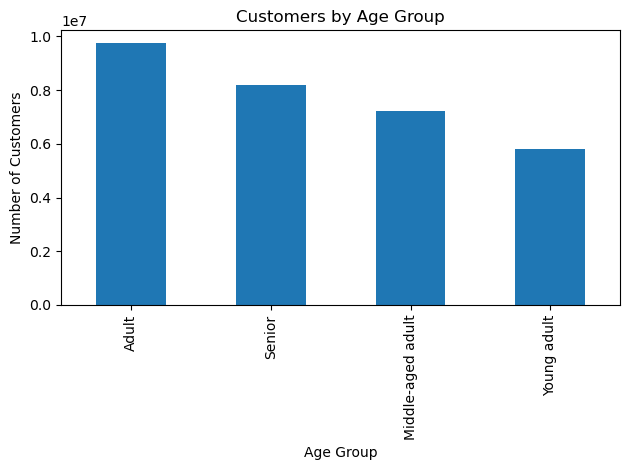

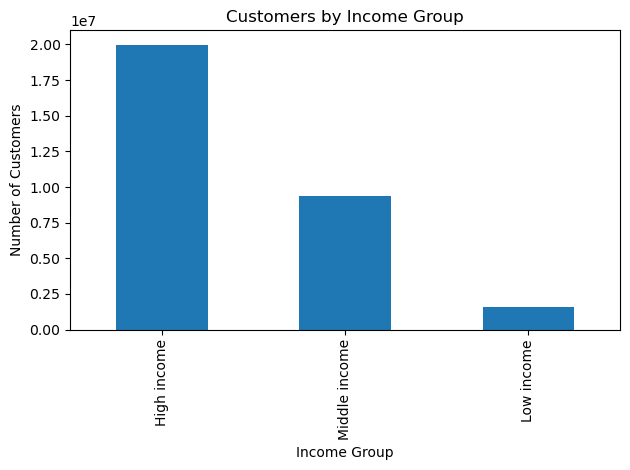

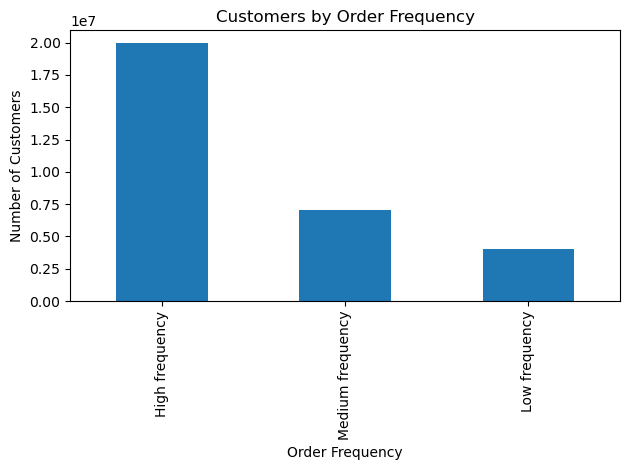

Saved to: /Users/a/Documents/Instacart Basket Analysis/04 Analysis/Visualizations


In [28]:
import os
import matplotlib.pyplot as plt

# Save path (Mac)
viz_path = "/Users/a/Documents/Instacart Basket Analysis/04 Analysis/Visualizations"
os.makedirs(viz_path, exist_ok=True)

# 1) Customers by Age Group
plt.figure()
df_filtered['age_group'].value_counts().plot(kind='bar')
plt.title('Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, "bar_customers_by_age_group.png"), dpi=300, bbox_inches="tight")
plt.show()

# 2) Customers by Income Group
plt.figure()
df_filtered['income_group'].value_counts().plot(kind='bar')
plt.title('Customers by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, "bar_customers_by_income_group.png"), dpi=300, bbox_inches="tight")
plt.show()

# 3) Customers by Order Frequency
plt.figure()
df_filtered['order_frequency'].value_counts().plot(kind='bar')
plt.title('Customers by Order Frequency')
plt.xlabel('Order Frequency')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(os.path.join(viz_path, "bar_customers_by_order_frequency.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", viz_path)

## 11. Summary: Customer profiling and segmentation readiness
This analysis prepared the Instacart dataset for customer profiling by systematically cleaning, segmenting, and validating both demographic and behavioral variables.

Key preparation steps included:
- Removal of personally identifiable information (PII) to ensure data privacy and ethical use
- Regional segmentation using U.S. Census regions to support geographic comparisons
- Exclusion of low-activity customers to focus the analysis on revenue-relevant behavior
- Creation and validation of core customer profile variables:
  - Age group (life-stage segmentation)
  - Income group (spending power segmentation)
  - Family status (number of dependents)
  - Order frequency (engagement segmentation)

Each segmentation step was validated to ensure realistic distributions and analytical relevance.

From a business perspective, these validated customer segments enable Instacart to move beyond one-size-fits-all strategies. By combining demographic context (age, income, and household structure) with engagement behavior, the company can design more targeted promotions, loyalty programs, and product strategies, while also adapting marketing approaches across geographic regions.

The resulting dataset provides a clear, interpretable foundation for downstream analysis and supports the strategic insights, visualizations, and recommendations developed in the final report.

In [22]:
# Aggregate engagement metrics at customer profile level

profile_aggregation = (
    df_filtered
    .groupby('customer_profile')
    .agg(
        min_orders=('total_orders', 'min'),
        mean_orders=('total_orders', 'mean'),
        max_orders=('total_orders', 'max'),
        customer_count=('user_id', 'nunique')
    )
    .sort_values('mean_orders', ascending=False)
)

profile_aggregation.head(10)

,min_orders,mean_orders,max_orders,customer_count
customer_profile,,,,
Middle-aged adult | Low income | No dependents | High frequency,20,51.510845,99,156
Middle-aged adult | Middle income | No dependents | High frequency,20,49.582078,99,428
Senior | Middle income | Large family | High frequency,20,48.547909,99,505
Young adult | High income | Large family | High frequency,20,48.364403,99,734
Middle-aged adult | High income | No dependents | High frequency,20,48.183397,99,2372
Senior | Low income | Small family | High frequency,20,48.181151,99,363
Adult | Middle income | No dependents | High frequency,20,48.080813,99,1578
Young adult | Middle income | No dependents | High frequency,20,47.604636,99,1416
Adult | Middle income | Small family | High frequency,20,47.566727,99,3143


### Aggregating customer profiles for comparison

Before comparing customer profiles across regions and departments, profile-level
metrics are aggregated to create a stable and interpretable analytical unit.

Rather than analyzing individual customers or orders, customer profiles are
summarized using engagement metrics (minimum, average, and maximum order counts)
and unique customer counts.

This aggregation reduces noise from individual behavior and ensures that
comparisons across regions reflect meaningful differences between customer
segments rather than isolated user activity.

## 11. Customer profiles across regions and departments

In [23]:
# Compare customer profiles across regions

profile_region = (
    df_filtered
    .groupby(['region', 'customer_profile'])
    .size()
    .reset_index(name='customer_count')
    .sort_values('customer_count', ascending=False)
)

profile_region.head(10)

,region,customer_profile,customer_count
276,South,Senior | High income | Small family | High fre...,733443
249,South,Middle-aged adult | High income | Small family...,630753
222,South,Adult | High income | Small family | High freq...,562613
384,West,Senior | High income | Small family | High fre...,554277
60,Midwest,Senior | High income | Small family | High fre...,512168
357,West,Middle-aged adult | High income | Small family...,472669
330,West,Adult | High income | Small family | High freq...,459489
33,Midwest,Middle-aged adult | High income | Small family...,445921
240,South,Adult | Middle income | Small family | High fr...,419893
6,Midwest,Adult | High income | Small family | High freq...,413630
